# 03 - Noise Generation Demo

This notebook demonstrates the validated noise-generation API. It uses a spatial subset to keep the demo interactive while still exercising the same package-facing call pattern used by a larger pipeline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from stormlab.config import NoiseGenerationConfig
from stormlab.noise import generate_noise, linear_interpolation, temporal_autocorrelation

In [2]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
OUTPUT_ROOT = REPO_ROOT / "output" / "examples_pipeline"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data root exists: {DATA_ROOT.exists()}")

Repo root: c:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab
Data root exists: True


In [3]:
ar_id = 202200018
covariate_dir = DATA_ROOT / "cesm2" / "cesm2_rainstorm_covariates"
matched_rainfall_dir = DATA_ROOT / "cesm2" / "matched_aorc_rainfall"

raw_cesm_prcp = xr.load_dataset(covariate_dir / f"{ar_id}_prect_cesm_res.nc")["prect"].data
auto_corr = temporal_autocorrelation(raw_cesm_prcp)

aorc_rainfall = np.load(matched_rainfall_dir / f"{ar_id}_sr_rainfall.npy")
u_coarse = xr.load_dataset(covariate_dir / f"{ar_id}_u850_cesm_res.nc")["u850"].data
v_coarse = xr.load_dataset(covariate_dir / f"{ar_id}_v850_cesm_res.nc")["v850"].data

print(f"AORC rainfall shape: {aorc_rainfall.shape}")
print(f"Coarse wind shape: {u_coarse.shape}")
print(f"Autocorrelation shape: {auto_corr.shape}")

AORC rainfall shape: (27, 630, 1024)
Coarse wind shape: (27, 24, 29)
Autocorrelation shape: (27,)


In [4]:
# Coordinates used by the original example notebooks.
aorc_lat = np.linspace(50, 29, 630)
aorc_lon = np.linspace(-113.16734, -79.068704, 1024)
cesm_lat = np.linspace(50.41884817, 28.7434555, 24)
cesm_lon = np.linspace(-113.75, -78.75, 29)

# Small subset for interactive EDA.
time_subset = slice(0, 4)
y_subset = slice(240, 368)
x_subset = slice(420, 548)

sub_lat = aorc_lat[y_subset]
sub_lon = aorc_lon[x_subset]
sub_prcp = np.where(aorc_rainfall[time_subset, y_subset, x_subset] < 0.2, 0, aorc_rainfall[time_subset, y_subset, x_subset])
sub_acf = auto_corr[time_subset]

u_high = np.zeros_like(sub_prcp)
v_high = np.zeros_like(sub_prcp)
for t in range(sub_prcp.shape[0]):
    u_high[t] = linear_interpolation(u_coarse[t], cesm_lon, cesm_lat, sub_lon, sub_lat)
    v_high[t] = linear_interpolation(v_coarse[t], cesm_lon, cesm_lat, sub_lon, sub_lat)

print(f"Subset precip shape: {sub_prcp.shape}")
print(f"Subset wet fraction: {np.mean(sub_prcp > 0):.3f}")

Subset precip shape: (4, 128, 128)
Subset wet fraction: 0.273


In [5]:
config = NoiseGenerationConfig(
    window_size=(64, 64),
    overlap_ratio=0.3,
    ssft_war_thr=0.1,
    seed=1,
)

# Wind is converted from m/s-like source units to displacement over a 6-hour step, following the original notebook.
noise = generate_noise(
    sub_prcp,
    sub_acf,
    u_high * 3600 * 6,
    v_high * 3600 * 6,
    sub_lon,
    sub_lat,
    config,
)

print(f"Noise shape: {noise.shape}")
print(f"Noise mean/std: {noise.mean():.3f} / {noise.std():.3f}")

Noise shape: (4, 128, 128)
Noise mean/std: nan / nan


C:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab\src\noise_generation.py:36: RuntimeWarning: invalid value encountered in divide
  F.imag = (F.imag - np.mean(F.imag)) / np.std(F.imag)
C:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab\src\noise_generation.py:37: RuntimeWarning: invalid value encountered in divide
  F.real = (F.real - np.mean(F.real)) / np.std(F.real)


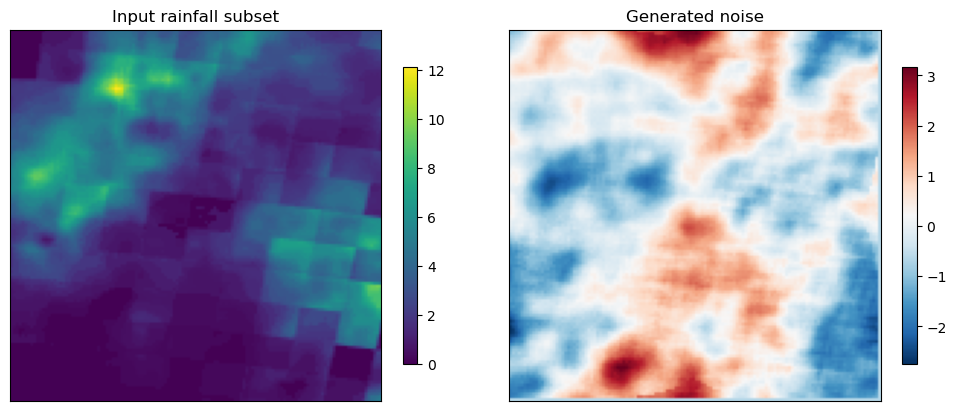

In [6]:
time_index = 0
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im0 = axes[0].imshow(sub_prcp[time_index], origin="upper")
axes[0].set_title("Input rainfall subset")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(noise[time_index], origin="upper", cmap="RdBu_r")
axes[1].set_title("Generated noise")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [ ]:
# Optional save.
# np.save(OUTPUT_ROOT / "noise_subset.npy", noise)